Load Requirements

In [1]:
import sys
!{sys.executable} -m pip install tensorflow==2.10.0

In [2]:
import sys
!{sys.executable} -m pip install numpy==1.23.5
!{sys.executable} -m pip install opencv-python==4.7.0.72

In [3]:
import numpy as np
import cv2
import tensorflow as tf

print("Numpy:", np.__version__)    # should be 1.23.5
print("OpenCV:", cv2.__version__)  # should be 4.8.0
print("TF:", tf.__version__)       # should be 2.10.0
print("GPUs:", tf.config.list_physical_devices('GPU'))

Numpy: 1.23.5
OpenCV: 4.7.0
TF: 2.10.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import os  

In [5]:
## Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu,True)

Remove Dodgy Images

In [6]:
data_dir = 'data'

In [7]:
data_dir

'data'

In [8]:
import os
import cv2

image_exts = ['jpeg', 'jpg', 'bmp', 'png']

for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            # Check extension manually
            ext = image.split('.')[-1].lower()
            if ext not in image_exts:
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
                continue
            
            # Check if image is readable
            img = cv2.imread(image_path)
            if img is None:
                print('Corrupted image {}'.format(image_path))
                os.remove(image_path)
                
        except Exception as e:
            print('Issue with image {}'.format(image_path))

Load Data

In [9]:
tf.data.Dataset.list_files

<function tensorflow.python.data.ops.dataset_ops.DatasetV2.list_files(file_pattern, shuffle=None, seed=None, name=None)>

In [10]:
import sys
!{sys.executable} -m pip install matplotlib

In [11]:
import matplotlib.pyplot as plt 

In [13]:
tf.keras.utils.image_dataset_from_directory??


Signature:
tf.keras.utils.image_dataset_from_directory(
    directory,
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
    **kwargs,
)
Source:   
@keras_export(
    "keras.utils.image_dataset_from_directory",
    "keras.preprocessing.image_dataset_from_directory",
    v1=[],
)
def image_dataset_from_directory(
    directory,
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    **kwargs,
):
    """Generates a `tf.data.Dataset` from image files in a directory.

    If your directory structure is:



In [12]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 173 files belonging to 2 classes.


In [17]:
data_iterator = data.as_numpy_iterator()

In [19]:
data_iterator

In [32]:
batch = data_iterator.next()

In [33]:
batch[0].shape
# batch give the array of two  , which [0] has {32,256,256,3} meaing 32 images, pixels size, rgb 
#  ans [1] mean label of dataImages

(32, 256, 256, 3)

In [35]:
# class 1 = SAD PPL 
# class 0 = HAPPY PPL
batch[1]

array([0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0])

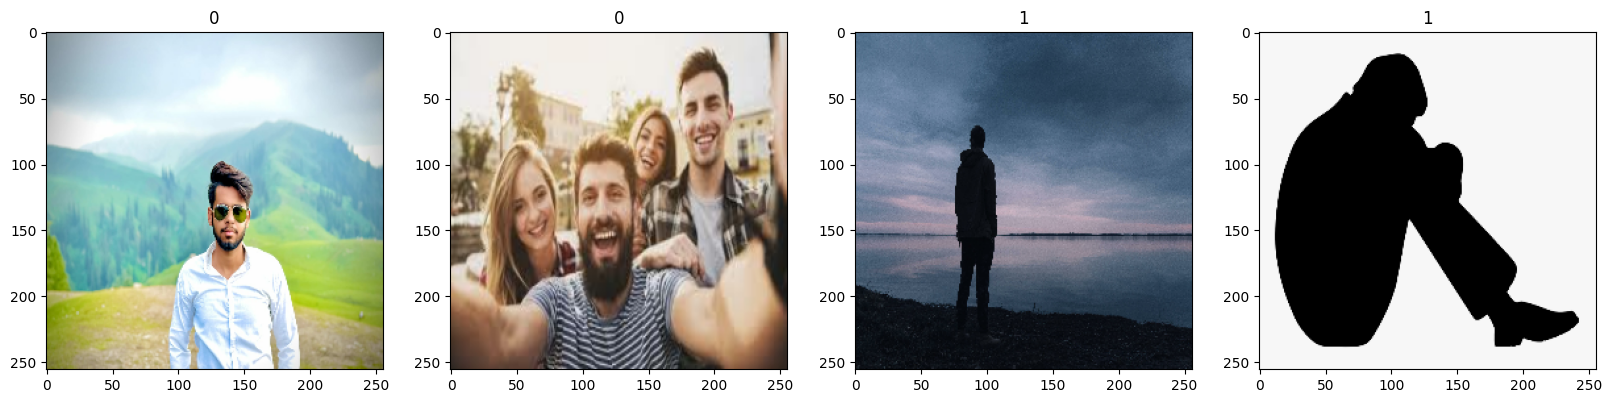

In [34]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])